<a href="https://colab.research.google.com/github/lipikaise2026-stack/Machine-Learning-Projects/blob/main/california_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STEP 1: DATA COLLECTION
# Load the California Housing dataset
# ============================================================

from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
housing = fetch_california_housing()

# Convert dataset into a pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column (House Price)
df["HousePrice"] = housing.target

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# ============================================================
# STEP 2: DATA CLEANING
# Check missing values and duplicate records
# ============================================================

# Dataset information
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any exist
df = df.drop_duplicates()

print("\nDataset Shape after Cleaning:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Duplicate Rows: 0

Dataset Shape after Cleaning: (20640, 9)


In [3]:
# ============================================================
# STEP 3: DATA PREPROCESSING
# Split features and target, then scale the features
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features (X) and Target (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 16512
Testing Samples: 4128


HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64


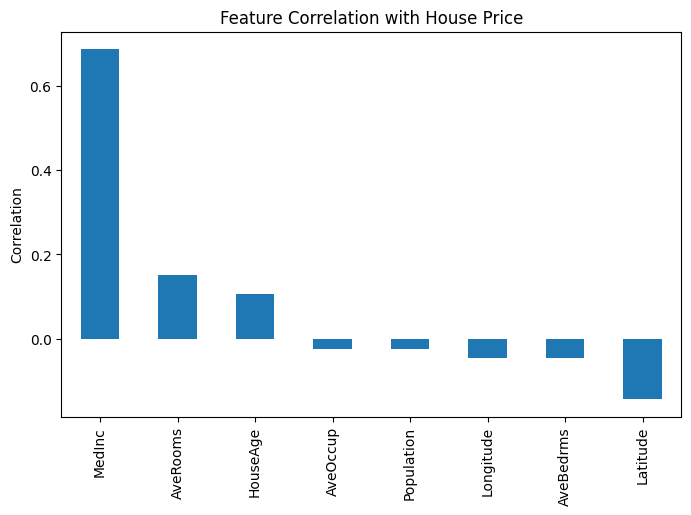

In [4]:
# ============================================================
# STEP 4: FEATURE ENGINEERING / FEATURE SELECTION
# Select important features using correlation
# ============================================================

import matplotlib.pyplot as plt

# Correlation with target
correlation = df.corr()["HousePrice"].sort_values(ascending=False)

print(correlation)

# Plot correlation
plt.figure(figsize=(8,5))
correlation.drop("HousePrice").plot(kind="bar")
plt.title("Feature Correlation with House Price")
plt.ylabel("Correlation")
plt.show()

In [5]:
# ============================================================
# STEP 5: MODEL SELECTION
# We'll use Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

print(model)

LinearRegression()


In [6]:
# ============================================================
# STEP 6: MODEL TRAINING
# Train the Linear Regression model
# ============================================================

model.fit(X_train_scaled, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [7]:
# ============================================================
# STEP 7: MODEL EVALUATION
# Evaluate model performance
# ============================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test_scaled)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 0.5332001304956565
Mean Squared Error: 0.5558915986952442
Root Mean Squared Error: 0.7455813830127763
R² Score: 0.575787706032451


In [8]:
# ============================================================
# STEP 8: HYPERPARAMETER TUNING
# Tune a Random Forest Regressor using GridSearchCV
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Parameter Grid
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross Validation Score: 0.7793535803692704


In [9]:
# ============================================================
# STEP 9: DEPLOYMENT
# Save the trained model and scaler
# ============================================================

import joblib

# Save model
joblib.dump(model, "california_house_price_model.pkl")

# Save scaler
joblib.dump(scaler, "feature_scaler.pkl")

print("Model and Scaler Saved Successfully!")

Model and Scaler Saved Successfully!


In [10]:
# ============================================================
# STEP 10: MONITORING & MAINTENANCE
# Load the saved model and make predictions
# ============================================================

# Load saved model
loaded_model = joblib.load("california_house_price_model.pkl")

# Predict again
predictions = loaded_model.predict(X_test_scaled[:5])

print("Sample Predictions:")
print(predictions)

print("\nActual Values:")
print(y_test.iloc[:5].values)

Sample Predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]

Actual Values:
[0.477   0.458   5.00001 2.186   2.78   ]
